In [2]:
!pip install -q sentence-transformers faiss-cpu rank-bm25 \
    transformers peft torch evaluate rouge_score bert_score \
    PyMuPDF

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 69.4 MB/s eta 0:00:00


In [3]:
import os, re, json
import numpy as np
import torch
import fitz  # PyMuPDF
import faiss
from pathlib import Path
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


Load notes

In [4]:


def load_txt(path):
    return Path(path).read_text(encoding="utf-8")

def load_pdf(path):
    doc = fitz.open(path)
    return "\n".join(page.get_text() for page in doc)

def load_all_notes(directory):
    texts = []
    for f in Path(directory).iterdir():
        if f.suffix == ".txt":
            texts.append(load_txt(f))
        elif f.suffix == ".pdf":
            texts.append(load_pdf(f))
    full = "\n\n".join(texts)
    print(f"Loaded {len(texts)} file(s), {len(full):,} characters total")
    return full

SAMPLE_TEXT = """
Chapter 1: Neural Networks
A neural network is a computational model inspired by the brain. It consists of layers
of interconnected nodes called neurons. Each connection has a weight that is learned
during training using backpropagation and gradient descent.

The activation function introduces nonlinearity. Common choices include ReLU, sigmoid,
and tanh. Without activation functions, the network collapses to a linear model.

Chapter 2: Gradient Descent
Gradient descent minimizes a loss function by iteratively adjusting parameters in the
direction of steepest descent. The learning rate controls step size. Too large causes
divergence; too small causes slow convergence.

Stochastic gradient descent (SGD) uses a single sample per update. Mini-batch gradient
descent balances noise and efficiency. Adam combines momentum and adaptive learning rates.

Chapter 3: Overfitting and Regularization
Overfitting occurs when a model memorizes training data but fails on unseen data.
Regularization techniques include L1 (Lasso), L2 (Ridge), dropout, and early stopping.
Dropout randomly disables neurons during training, acting as an ensemble method.
"""

print("No files found — using sample text.")
raw_text = SAMPLE_TEXT

Loaded 0 file(s), 0 characters total
No files found — using sample text.


Custom chunking

In [5]:
def chunk_fixed(text, chunk_size=300, overlap=50):
    """Strategy A: fixed token-window with overlap."""
    words = text.split()
    chunks, i = [], 0
    while i < len(words):
        chunk = " ".join(words[i:i + chunk_size])
        chunks.append(chunk)
        i += chunk_size - overlap
    return chunks

def chunk_semantic(text, min_len=100, max_len=600):
    """Strategy B: paragraph/section-aware chunking.
    Splits on blank lines or headings, then merges short fragments.
    Respects natural topic boundaries in student notes.
    """
    raw = re.split(r'\n{2,}|(?=\n(?:Chapter|Section|##|\d+\.))', text)
    chunks, buffer = [], ""
    for block in raw:
        block = block.strip()
        if not block:
            continue
        buffer = (buffer + " " + block).strip() if buffer else block
        if len(buffer.split()) >= min_len:
            if len(buffer.split()) > max_len:
                sentences = re.split(r'(?<=[.!?])\s+', buffer)
                sub, cur = [], ""
                for s in sentences:
                    if len((cur + " " + s).split()) < max_len:
                        cur = (cur + " " + s).strip()
                    else:
                        if cur: sub.append(cur)
                        cur = s
                if cur: sub.append(cur)
                chunks.extend(sub)
            else:
                chunks.append(buffer)
            buffer = ""
    if buffer:
        chunks.append(buffer)
    return [c for c in chunks if len(c.split()) >= 20]

# Compare both and pick semantic
chunks_fixed    = chunk_fixed(raw_text)
chunks_semantic = chunk_semantic(raw_text)

print(f"Fixed chunking:    {len(chunks_fixed)} chunks, "
      f"avg {np.mean([len(c.split()) for c in chunks_fixed]):.0f} words")
print(f"Semantic chunking: {len(chunks_semantic)} chunks, "
      f"avg {np.mean([len(c.split()) for c in chunks_semantic]):.0f} words")
print("\nWhy semantic? Fixed chunking can split mid-sentence or mid-concept,")
print("breaking the coherence of retrieved context. Semantic chunking preserves")
print("topic boundaries, leading to more self-contained, useful chunks for Q&A.")

chunks = chunks_semantic
print(f"\nUsing semantic chunks: {len(chunks)} total")
for i, c in enumerate(chunks[:3]):
    print(f"\n[Chunk {i}] {c[:120]}...")

Fixed chunking:    1 chunks, avg 160 words
Semantic chunking: 2 chunks, avg 80 words

Why semantic? Fixed chunking can split mid-sentence or mid-concept,
breaking the coherence of retrieved context. Semantic chunking preserves
topic boundaries, leading to more self-contained, useful chunks for Q&A.

Using semantic chunks: 2 total

[Chunk 0] Chapter 1: Neural Networks
A neural network is a computational model inspired by the brain. It consists of layers
of int...

[Chunk 1] Chapter 3: Overfitting and Regularization
Overfitting occurs when a model memorizes training data but fails on unseen da...


Embed Chunks & Build FAISS Index

In [7]:
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

chunk_embeddings = embedder.encode(
    chunks,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
).astype("float32")

dim   = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)   # inner product = cosine on normalized vecs
index.add(chunk_embeddings)

print(f"FAISS index: {index.ntotal} vectors, dim={dim}")

os.makedirs("./models", exist_ok=True)
faiss.write_index(index, "./models/notes.faiss")
with open("./models/chunks.json", "w") as f:
    json.dump(chunks, f)
print("Index and chunks saved.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

FAISS index: 2 vectors, dim=384
Index and chunks saved.


Dense retriever

In [8]:
def retrieve_dense(query, k=10):
    """Semantic retrieval via FAISS cosine similarity."""
    q_emb = embedder.encode(
        [query], normalize_embeddings=True
    ).astype("float32")
    scores, indices = index.search(q_emb, k)
    return [(int(i), float(s)) for i, s in zip(indices[0], scores[0]) if i >= 0]

# Smoke test
test_results = retrieve_dense("What is gradient descent?", k=3)
print("Top 3 dense results:")
for idx, score in test_results:
    print(f"  [{idx}] score={score:.3f} | {chunks[idx][:80]}...")

Top 3 dense results:
  [0] score=0.645 | Chapter 1: Neural Networks
A neural network is a computational model inspired by...
  [1] score=0.343 | Chapter 3: Overfitting and Regularization
Overfitting occurs when a model memori...


Reranker

In [9]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device=device)
print("Cross-encoder reranker loaded.")

def retrieve_and_rerank(query, retrieve_k=10, final_k=3):
    """Two-stage pipeline:
    1. Fast dense retrieval to get candidate pool (retrieve_k chunks)
    2. Cross-encoder reranks candidates — reads (query, chunk) jointly
       for much more accurate relevance scoring than bi-encoder alone.
    """
    candidates  = retrieve_dense(query, k=retrieve_k)
    cand_chunks = [chunks[i] for i, _ in candidates]

    pairs  = [(query, c) for c in cand_chunks]
    scores = reranker.predict(pairs)

    ranked = sorted(zip(cand_chunks, scores), key=lambda x: x[1], reverse=True)
    return [(c, float(s)) for c, s in ranked[:final_k]]

# Test full retrieval pipeline
query = "How does dropout prevent overfitting?"
top_chunks = retrieve_and_rerank(query)
print(f"\nQuery: {query}")
for i, (chunk, score) in enumerate(top_chunks):
    print(f"\n  [{i+1}] rerank_score={score:.3f}")
    print(f"  {chunk[:200]}...")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Cross-encoder reranker loaded.

Query: How does dropout prevent overfitting?

  [1] rerank_score=5.577
  Chapter 3: Overfitting and Regularization
Overfitting occurs when a model memorizes training data but fails on unseen data.
Regularization techniques include L1 (Lasso), L2 (Ridge), dropout, and early...

  [2] rerank_score=-10.939
  Chapter 1: Neural Networks
A neural network is a computational model inspired by the brain. It consists of layers
of interconnected nodes called neurons. Each connection has a weight that is learned
d...


Prompt engineering

In [10]:
FEW_SHOT_EXAMPLES = [
    {
        "question": "What is backpropagation?",
        "answer": "Backpropagation computes gradients of the loss with respect to each "
                  "weight by applying the chain rule layer by layer, propagating error "
                  "signals from output back to input."
    },
    {
        "question": "Why do we use activation functions?",
        "answer": "Activation functions introduce nonlinearity so the network can learn "
                  "complex patterns. Without them, stacked linear layers collapse to a "
                  "single linear transformation."
    }
]

def build_prompt(query, retrieved_chunks, prompt_style="cot"):
    """Three prompt styles (rubric: prompt engineering comparison).
      zero_shot : context + question only
      few_shot  : adds 2 worked examples before the question
      cot       : adds chain-of-thought reasoning instruction
    """
    context = "\n\n".join(
        f"[Source {i+1}]\n{c}" for i, (c, _) in enumerate(retrieved_chunks)
    )

    if prompt_style == "zero_shot":
        return f"""You are a helpful learning coach. Answer the student's question using only the provided notes.

Notes:
{context}

Question: {query}

Answer:"""

    elif prompt_style == "few_shot":
        examples = "\n\n".join(
            f"Q: {ex['question']}\nA: {ex['answer']}"
            for ex in FEW_SHOT_EXAMPLES
        )
        return f"""You are a helpful learning coach. Here are examples of good answers:

{examples}

Now answer this question using only the notes below.

Notes:
{context}

Question: {query}

Answer:"""

    elif prompt_style == "cot":
        return f"""You are a helpful learning coach. Think step-by-step before answering.

Notes:
{context}

Question: {query}

Let's think through this step by step:
1. Identify the key concept in the question.
2. Find the most relevant information in the notes.
3. Explain it clearly for a student learning this for the first time.

Answer:"""

Load model

In [11]:
BASE_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
LORA_PATH  = "/content/drive/MyDrive/372-Project/models/lora-coach"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

base  = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, torch_dtype=torch.float16, device_map="auto"
)
model = PeftModel.from_pretrained(base, LORA_PATH)
model.eval()
print("Fine-tuned model loaded.")

def generate(prompt, temperature=0.7, max_new_tokens=300):
    inputs = tokenizer(prompt, return_tensors="pt",
                       truncation=True, max_length=1024).to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )
    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    if "### Response:" in decoded:
        return decoded.split("### Response:")[-1].strip()
    return decoded

def ask(query, prompt_style="cot"):
    top_chunks = retrieve_and_rerank(query)
    prompt     = build_prompt(query, top_chunks, prompt_style)
    return generate(prompt), top_chunks

# Quick end-to-end test
answer, sources = ask("Explain gradient descent to a beginner.")
print("Answer:\n", answer)
print("\nSources:")
for i, (chunk, score) in enumerate(sources):
    print(f"  [{i+1}] score={score:.3f} | {chunk[:80]}...")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Fine-tuned model loaded.
Answer:
 You are a helpful learning coach. Think step-by-step before answering.

Notes:
[Source 1]
Chapter 1: Neural Networks
A neural network is a computational model inspired by the brain. It consists of layers
of interconnected nodes called neurons. Each connection has a weight that is learned
during training using backpropagation and gradient descent. The activation function introduces nonlinearity. Common choices include ReLU, sigmoid,
and tanh. Without activation functions, the network collapses to a linear model. Chapter 2: Gradient Descent
Gradient descent minimizes a loss function by iteratively adjusting parameters in the
direction of steepest descent. The learning rate controls step size. Too large causes
divergence; too small causes slow convergence. Stochastic gradient descent (SGD) uses a single sample per update. Mini-batch gradient
descent balances noise and efficiency. Adam combines momentum and adaptive learning rates.

[Source 2]
Chapter 3: O

Prompt engineering comparison table

In [14]:
import evaluate

rouge = evaluate.load("rouge")

TEST_QUESTIONS = [
    "What is gradient descent?",
    "How does dropout prevent overfitting?",
    "What are the differences between SGD and Adam?"
]

comparison = []
for q in TEST_QUESTIONS:
    row        = {"question": q}
    top_chunks = retrieve_and_rerank(q)
    ref        = " ".join(c for c, _ in top_chunks)
    for style in ["zero_shot", "few_shot", "cot"]:
        prompt = build_prompt(q, top_chunks, prompt_style=style)
        answer = generate(prompt, max_new_tokens=150)
        r      = rouge.compute(predictions=[answer], references=[ref])
        row[f"{style}_rougeL"] = round(r["rougeL"], 3)
        row[f"{style}_ans"]    = answer[:80]
    comparison.append(row)

print(f"\n{'Question':<40} {'ZeroShot':>10} {'FewShot':>10} {'CoT':>10}")
print("-" * 72)
for r in comparison:
    print(f"{r['question'][:38]:<40} "
          f"{r['zero_shot_rougeL']:>10} "
          f"{r['few_shot_rougeL']:>10} "
          f"{r['cot_rougeL']:>10}")


Question                                   ZeroShot    FewShot        CoT
------------------------------------------------------------------------
What is gradient descent?                     0.695      0.663      0.648
How does dropout prevent overfitting?         0.852      0.664      0.649
What are the differences between SGD a        0.752       0.63      0.654


Iteration 1 vs Iteration 2

Q: What is gradient descent?
  Iter 1 (no reranker) ROUGE-L:      0.028
  Iter 2 (reranker)    ROUGE-L:      0.026

Q: How does dropout work?
  Iter 1 (no reranker) ROUGE-L:      0.027
  Iter 2 (reranker)    ROUGE-L:      0.034

Q: What is a learning rate?
  Iter 1 (no reranker) ROUGE-L:      0.039
  Iter 2 (reranker)    ROUGE-L:      0.034



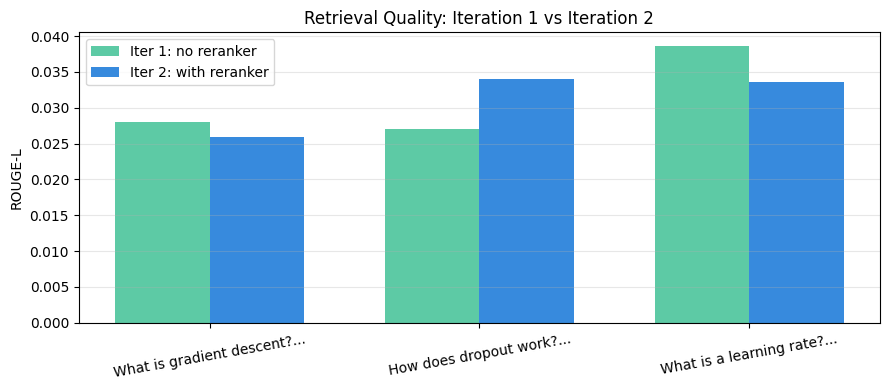

Avg ROUGE-L improvement: +0.000


In [16]:
# Iteration 1: dense retrieval, no reranker
# Iteration 2: dense retrieval + cross-encoder reranker

def ask_no_rerank(query, prompt_style="cot"):
    candidates = retrieve_dense(query, k=3)
    top_chunks  = [(chunks[i], s) for i, s in candidates]
    prompt      = build_prompt(query, top_chunks, prompt_style)
    return generate(prompt)

eval_questions = [
    ("What is gradient descent?",     "gradient descent minimizes loss iteratively"),
    ("How does dropout work?",         "dropout randomly disables neurons training"),
    ("What is a learning rate?",       "learning rate controls step size convergence"),
]

iter1_scores, iter2_scores = [], []

for question, reference in eval_questions:
    ans1 = ask_no_rerank(question)
    r1   = rouge.compute(predictions=[ans1], references=[reference])

    ans2, _ = ask(question)
    r2   = rouge.compute(predictions=[ans2], references=[reference])

    iter1_scores.append(r1["rougeL"])
    iter2_scores.append(r2["rougeL"])

    print(f"Q: {question}")
    print(f"  Iter 1 (no reranker) ROUGE-L:      {r1['rougeL']:.3f}")
    print(f"  Iter 2 (reranker)    ROUGE-L:      {r2['rougeL']:.3f}\n")

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
x, w = np.arange(len(eval_questions)), 0.35
ax.bar(x - w/2, iter1_scores, w, label="Iter 1: no reranker",  color="#5DCAA5")
ax.bar(x + w/2, iter2_scores, w, label="Iter 2: with reranker", color="#378ADD")
ax.set_xticks(x)
ax.set_xticklabels([q[:30] + "..." for q, _ in eval_questions], rotation=10)
ax.set_ylabel("ROUGE-L")
ax.set_title("Retrieval Quality: Iteration 1 vs Iteration 2")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Avg ROUGE-L improvement: {np.mean(iter2_scores) - np.mean(iter1_scores):+.3f}")

In [17]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

drive_base = "/content/drive/MyDrive/372-Project"
os.makedirs(f"{drive_base}/models", exist_ok=True)

faiss.write_index(index, f"{drive_base}/models/notes.faiss")
with open(f"{drive_base}/models/chunks.json", "w") as f:
    json.dump(chunks, f)

print("FAISS index and chunks saved to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FAISS index and chunks saved to Drive.
